<a href="https://colab.research.google.com/github/yusraanwar33-source/Deep-learning/blob/main/Spam_detection_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
pip install tensorflow pandas scikit-learn

In [13]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

#Load dataset

In [14]:

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', names=['label', 'message'])
print(df.head())
print("Class distribution:\n", df['label'].value_counts())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Class distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64


#Convert labels: ham=0, spam=1

In [15]:

df['label'] = df['label'].map({'ham': 0, 'spam': 1})


#Split data

In [16]:

X_train, X_test, y_train, y_test = train_test_split(
    df['message'], df['label'], test_size=0.2, random_state=42, stratify=df['label'])

#Tokenize and pad sequences

In [17]:

vocab_size = 5000
max_length = 100
oov_token = "<OOV>"

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

#Build LSTM model

In [18]:

model = models.Sequential([
    layers.Embedding(vocab_size, 64, input_length=max_length),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy', 'Precision', 'Recall'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#Train model

In [8]:

history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 125ms/step - Precision: 0.8289 - Recall: 0.5753 - accuracy: 0.9271 - loss: 0.1975 - val_Precision: 0.9926 - val_Recall: 0.8993 - val_accuracy: 0.9857 - val_loss: 0.0551
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - Precision: 0.9757 - Recall: 0.9398 - accuracy: 0.9888 - loss: 0.0415 - val_Precision: 0.9276 - val_Recall: 0.9463 - val_accuracy: 0.9830 - val_loss: 0.0576
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 118ms/step - Precision: 0.9880 - Recall: 0.9666 - accuracy: 0.9939 - loss: 0.0205 - val_Precision: 0.9856 - val_Recall: 0.9195 - val_accuracy: 0.9874 - val_loss: 0.0454
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 18s 127ms/step - Precision: 0.9932 - Recall: 0.9816 - accuracy: 0.9966 - loss: 0.0130 - val_Precision: 1.0000 - val_Recall: 0.9195 - val_accuracy: 0.9892 - val_loss: 0.0508
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - Precision: 0.9983 - Recall: 0.9900 - accuracy: 0.9984 - loss: 0.0061 - val_Precision: 0.985

#Evaluate

In [9]:

loss, acc, prec, rec = model.evaluate(X_test_pad, y_test)
print(f"\nTest Accuracy: {acc*100:.2f}%")
print(f"Precision: {prec:.2f}, Recall: {rec:.2f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - Precision: 0.9858 - Recall: 0.9329 - accuracy: 0.9892 - loss: 0.0878

Test Accuracy: 98.92%
Precision: 0.99, Recall: 0.93


#Plot training curve

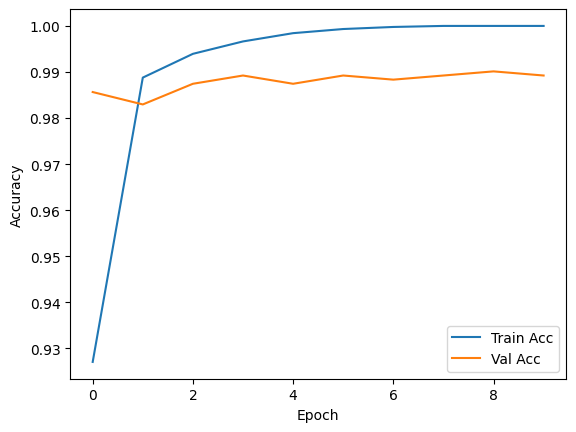

In [11]:

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Test it

In [19]:
# 10. Test it
print("\n--- Test Messages ---")
print("Msg 1:", predict_spam("Congratulations! You won a free iPhone. Click here now"))
print("Msg 2:", predict_spam("Hey, are we meeting tomorrow at 5pm?"))
print("Msg 3:", predict_spam("WINNER!! Claim your $1000 prize now by calling 090500"))


--- Test Messages ---
Msg 1: SPAM
Msg 2: HAM
Msg 3: HAM


#  Save model and tokenizer

In [20]:

model.save('spam_lstm_model.h5')
import pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("\nModel and tokenizer saved!")


Model and tokenizer saved!
